In [63]:
import math
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import yfinance as yf
from torch.utils.data import DataLoader, Dataset

from models import (
    LSTMRegression, LSTMClassifier, LSTMMultiTask,
    TransformerRegression, TransformerClassifier, TransformerMultiTask,
)


In [64]:
# ── Data ──────────────────────────────────────────────────────────────────────
# Multi-stock comparison: (symbol, market-cap label for tables/plots). Labels are
# illustrative — verify against current market-cap data if you cite them in a report.
STOCK_UNIVERSE: List[Tuple[str, str]] = [
    ("TSLA", "large-cap"),
    ("F", "mid-cap"),
    ("SOFI", "small-cap"),
]
COMPARE_ACROSS_STOCKS = True   # False → train only on TICKER_SINGLE (legacy single-ticker run)
TICKER_SINGLE = "AAPL"

TICKER = STOCK_UNIVERSE[0][0] if COMPARE_ACROSS_STOCKS else TICKER_SINGLE
CAP_LABELS: Dict[str, str] = {s: cap for s, cap in STOCK_UNIVERSE}

PERIOD = "3y"
INTERVAL = "1d"
MIN_ROWS_DOWNLOAD = 20

# ── Splits ────────────────────────────────────────────────────────────────────
TRAIN_FRAC   = 0.70
VAL_END_FRAC = 0.85
LOOKBACK     = 20
HORIZON      = 1
BATCH_SIZE   = 32

# ── Volatility features ───────────────────────────────────────────────────────
USE_VOL_FEATURES = False
NUM_VOL_FEATURES = 2
ATR_EWM_SPAN     = 14
RV_EWM_SPAN      = 19
INPUT_DIM = 5 + (NUM_VOL_FEATURES if USE_VOL_FEATURES else 0)

# ── Default LSTM architecture ─────────────────────────────────────────────────
LSTM_HIDDEN_SIZE = 64
LSTM_NUM_LAYERS  = 2
LSTM_DROPOUT     = 0.2

# ── Default Transformer architecture ─────────────────────────────────────────
TF_D_MODEL         = 32
TF_NHEAD           = 2
TF_NUM_LAYERS      = 2
TF_DROPOUT         = 0.127
TF_DIM_FEEDFORWARD = 256
TF_MAX_POS_LEN     = 5000

# ── Training ──────────────────────────────────────────────────────────────────
NUM_EPOCHS         = 200
LEARNING_RATE      = 0.002326
WEIGHT_DECAY       = 0.0001357
SCHEDULER_PATIENCE = 10
SCHEDULER_FACTOR   = 0.5
SCHEDULER_MIN_LR   = 1e-6
LOG_EVERY          = 20

# ── Loss weights (regression / multi-task) ────────────────────────────────────
VAR_WEIGHT       = 1.654
DIR_WEIGHT       = 0.566
HINGE_SCALE      = 0.440
MULTITASK_ALPHA  = 0.5   # weight on regression loss in multi-task (1-alpha = BCE weight)

# ── Optuna ────────────────────────────────────────────────────────────────────
RUN_OPTUNA              = False  # True: run hyperparameter search cells; False: skip (whole notebook one-click)
OPTUNA_N_TRIALS         = 20
OPTUNA_EPOCHS_PER_TRIAL = 80
OPTUNA_SEED             = 42

# ── Plotting ──────────────────────────────────────────────────────────────────
SAMPLE_IDX = 5

# Model registry — populated during training cells
RESULTS: Dict = {}
RESULTS_BY_TICKER: Dict[str, Dict] = {}   # symbol -> { model_key -> result dict }
DATA_BY_TICKER: Dict[str, dict] = {}       # symbol -> {df, prepared, cap}
FOCUS_TICKER = TICKER                     # plots / Optuna default focus


In [65]:
DEFAULT_FEATURE_COLUMNS = ["open", "high", "low", "close", "volume"]


def download_stock_data(ticker="AAPL", period="3y", interval="1d"):
    """Download OHLCV data and return a clean lowercase-column DataFrame."""
    data = yf.download(ticker, period=period, interval=interval,
                       auto_adjust=True, progress=False)
    if data.empty:
        raise ValueError(f"No data for {ticker!r}.")
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data = data.rename(columns={"Open": "open", "High": "high", "Low": "low",
                                 "Close": "close", "Volume": "volume"})
    cleaned = data[DEFAULT_FEATURE_COLUMNS].dropna().reset_index(drop=True)
    if len(cleaned) <= MIN_ROWS_DOWNLOAD:
        raise ValueError("Dataset too small.")
    return cleaned


In [66]:
class StockSequenceDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def create_sequences(X, y, lookback, horizon):
    X_seq, y_seq = [], []
    for end in range(lookback, len(X) - horizon + 1):
        X_seq.append(X[end - lookback : end])
        y_seq.append(y[end : end + horizon].reshape(-1))
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)


VOL_FEATURES = ("atr_pct", "rv_ewm")


def compute_returns(df, use_vol=None, atr_ewm_span=None, rv_ewm_span=None):
    if use_vol is None:
        use_vol = USE_VOL_FEATURES
    atr_span = ATR_EWM_SPAN if atr_ewm_span is None else atr_ewm_span
    rv_span  = RV_EWM_SPAN  if rv_ewm_span  is None else rv_ewm_span

    out = df[["open", "high", "low", "close", "volume"]].pct_change().copy()
    out.columns = ["open_ret", "high_ret", "low_ret", "close_ret", "volume_ret"]

    if use_vol:
        prev_close = df["close"].shift(1)
        tr = pd.concat([df["high"] - df["low"],
                        (df["high"] - prev_close).abs(),
                        (df["low"]  - prev_close).abs()], axis=1).max(axis=1)
        out["atr_pct"] = (tr / prev_close).ewm(span=atr_span, adjust=False).mean()
        out["rv_ewm"]  = out["close_ret"].ewm(span=rv_span, adjust=False).std()
    return out.dropna()


def prepare_datasets(df, feature_columns=None, target_column="close_ret",
                     lookback=20, horizon=1, batch_size=32,
                     use_vol_features=None, atr_ewm_span=None, rv_ewm_span=None):
    use_vol    = USE_VOL_FEATURES if use_vol_features is None else use_vol_features
    returns_df = compute_returns(df, use_vol=use_vol,
                                 atr_ewm_span=atr_ewm_span, rv_ewm_span=rv_ewm_span)

    base_feats      = ["open_ret", "high_ret", "low_ret", "close_ret", "volume_ret"]
    feature_columns = feature_columns or (base_feats + list(VOL_FEATURES) if use_vol else base_feats)
    returns_df      = returns_df.dropna().copy()

    n         = len(returns_df)
    train_end = int(n * TRAIN_FRAC)
    val_end   = int(n * VAL_END_FRAC)

    train_df = returns_df.iloc[:train_end].copy()
    val_df   = returns_df.iloc[train_end - lookback : val_end].copy()
    test_df  = returns_df.iloc[val_end  - lookback :].copy()

    if use_vol:
        for c in VOL_FEATURES:
            mu, sig = train_df[c].mean(), train_df[c].std() + 1e-8
            for part in (train_df, val_df, test_df):
                part[c] = (part[c] - mu) / sig

    def _seq(part):
        X = part[feature_columns].values.astype(np.float32)
        y = part[[target_column]].values.astype(np.float32)
        return create_sequences(X, y, lookback, horizon)

    train_X, train_y = _seq(train_df)
    val_X,   val_y   = _seq(val_df)
    test_X,  test_y  = _seq(test_df)

    mk = lambda X, y, shuf, drop: DataLoader(
        StockSequenceDataset(X, y), batch_size=batch_size,
        shuffle=shuf, drop_last=drop, num_workers=0)

    return {
        "dataloaders": {
            "train": mk(train_X, train_y, False, True),
            "val":   mk(val_X,   val_y,   False, False),
            "test":  mk(test_X,  test_y,  False, False),
        },
        "train_df": train_df, "val_df": val_df,
        "test_df":  test_df,  "returns_df": returns_df,
    }


In [67]:
def _download_and_prepare(sym: str):
    d = download_stock_data(ticker=sym, period=PERIOD, interval=INTERVAL)
    p = prepare_datasets(d, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE)
    return d, p


if COMPARE_ACROSS_STOCKS:
    DATA_BY_TICKER = {}
    for sym, cap in STOCK_UNIVERSE:
        df_s, prep_s = _download_and_prepare(sym)
        DATA_BY_TICKER[sym] = {"df": df_s, "prepared": prep_s, "cap": cap}
        tl = prep_s["dataloaders"]["train"]
        print(f"Downloaded {len(df_s)} rows for {sym} ({cap})  ({PERIOD} @ {INTERVAL})  | "
              f"train/val/test samples: {len(tl.dataset)} / "
              f"{len(prep_s['dataloaders']['val'].dataset)} / "
              f"{len(prep_s['dataloaders']['test'].dataset)}")
    FOCUS_TICKER = STOCK_UNIVERSE[0][0]
    df = DATA_BY_TICKER[FOCUS_TICKER]["df"]
    prepared = DATA_BY_TICKER[FOCUS_TICKER]["prepared"]
else:
    df, prepared = _download_and_prepare(TICKER)
    DATA_BY_TICKER = {TICKER: {"df": df, "prepared": prepared, "cap": ""}}
    FOCUS_TICKER = TICKER
    print(f"Downloaded {len(df)} rows for {TICKER}  ({PERIOD} @ {INTERVAL})")

train_loader = prepared["dataloaders"]["train"]
val_loader   = prepared["dataloaders"]["val"]
test_loader  = prepared["dataloaders"]["test"]

bX, by = next(iter(train_loader))
print(f"\nFocus ticker for legacy cells / Optuna: {FOCUS_TICKER}")
print(f"X shape: {bX.shape}  |  y shape: {by.shape}")
print(f"Train / val / test samples: "
      f"{len(train_loader.dataset)} / {len(val_loader.dataset)} / {len(test_loader.dataset)}")


Downloaded 753 rows for TSLA (large-cap)  (3y @ 1d)  | train/val/test samples: 506 / 113 / 113
Downloaded 753 rows for F (mid-cap)  (3y @ 1d)  | train/val/test samples: 506 / 113 / 113
Downloaded 753 rows for SOFI (small-cap)  (3y @ 1d)  | train/val/test samples: 506 / 113 / 113

Focus ticker for legacy cells / Optuna: TSLA
X shape: torch.Size([32, 20, 5])  |  y shape: torch.Size([32, 1])
Train / val / test samples: 506 / 113 / 113


In [68]:
class StockReturnLoss(nn.Module):
    """MSE + batch-std match + directional hinge penalty."""

    def __init__(self, var_weight=1.0, dir_weight=0.3, hinge_scale=0.5):
        super().__init__()
        self.var_weight  = var_weight
        self.dir_weight  = dir_weight
        self.hinge_scale = hinge_scale

    def forward(self, pred, target):
        mse     = F.mse_loss(pred, target)
        std_pen = (pred.std(dim=0).mean() - target.std(dim=0).mean()).pow(2)
        mask    = target != 0
        if mask.any():
            dir_hinge = (
                (torch.relu(1.0 - pred * torch.sign(target)) * mask.float()).sum()
                / mask.float().sum().clamp(min=1.0)
            )
        else:
            dir_hinge = pred.new_tensor(0.0)
        dir_pen = torch.relu(-pred * target).mean() + self.hinge_scale * dir_hinge
        return mse + self.var_weight * std_pen + self.dir_weight * dir_pen


class MultiTaskLoss(nn.Module):
    """alpha * StockReturnLoss(reg) + (1-alpha) * BCE(cls)."""

    def __init__(self, alpha=0.5, var_weight=1.0, dir_weight=0.3, hinge_scale=0.5):
        super().__init__()
        self.alpha    = alpha
        self.reg_loss = StockReturnLoss(var_weight, dir_weight, hinge_scale)

    def forward(self, reg_out, cls_out, y_reg):
        y_cls = (y_reg > 0).float()
        return (self.alpha * self.reg_loss(reg_out, y_reg)
                + (1 - self.alpha) * F.binary_cross_entropy(cls_out, y_cls))


def build_criterion(mode, **kw):
    """Factory: returns the appropriate loss object for the given mode."""
    vw, dw, hs = kw.get("var_weight", VAR_WEIGHT), kw.get("dir_weight", DIR_WEIGHT), kw.get("hinge_scale", HINGE_SCALE)
    if mode == "regression":
        return StockReturnLoss(vw, dw, hs)
    elif mode == "classification":
        return None   # BCE computed inline
    else:
        return MultiTaskLoss(kw.get("alpha", MULTITASK_ALPHA), vw, dw, hs)


In [69]:
def dir_accuracy(pred: torch.Tensor, target: torch.Tensor, mode: str = "regression") -> float:
    """
    Directional accuracy for any mode:
      regression / multitask_reg: sign(pred) == sign(target)
      classification / multitask_cls: (pred > 0.5) == (target > 0)
    """
    p, t = pred.squeeze(), target.squeeze()
    mask = t != 0
    if mask.sum().item() == 0:
        return float("nan")
    if mode == "classification":
        return ((p[mask] > 0.5) == (t[mask] > 0)).float().mean().item()
    else:
        return (torch.sign(p[mask]) == torch.sign(t[mask])).float().mean().item()


def run_epoch(model, loader, mode, criterion, device, optimizer=None):
    """One train or eval epoch. Returns (avg_loss, dir_acc)."""
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, all_preds, all_true = 0.0, [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            if mode == "regression":
                out  = model(X)
                loss = criterion(out, y)
                pred_for_dir = out
            elif mode == "classification":
                out  = model(X)
                loss = F.binary_cross_entropy(out, (y > 0).float())
                pred_for_dir = out
            else:  # multitask
                reg_out, cls_out = model(X)
                loss = criterion(reg_out, cls_out, y)
                pred_for_dir = reg_out  # sign comparison works on continuous returns

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * X.size(0)
        all_preds.append(pred_for_dir.detach().cpu())
        all_true.append(y.detach().cpu())

    preds    = torch.cat(all_preds)
    trues    = torch.cat(all_true)
    avg_loss = total_loss / len(loader.dataset)
    acc      = dir_accuracy(preds, trues, mode)
    return avg_loss, acc


def train_model(model, train_loader, val_loader, device, mode="regression",
                num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY, criterion=None, log_every=LOG_EVERY, label=""):
    """Generic training loop for all three modes."""
    if criterion is None:
        criterion = build_criterion(mode)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=SCHEDULER_PATIENCE,
        factor=SCHEDULER_FACTOR, min_lr=SCHEDULER_MIN_LR,
    )

    history = {"train_loss": [], "val_loss": [], "train_dir": [], "val_dir": []}
    best_val, best_state = float("inf"), None

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_dir = run_epoch(model, train_loader, mode, criterion, device, optimizer)
        vl_loss, vl_dir = run_epoch(model, val_loader,   mode, criterion, device)
        scheduler.step(vl_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_dir"].append(tr_dir)
        history["val_dir"].append(vl_dir)

        if vl_loss < best_val:
            best_val   = vl_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % log_every == 0:
            print(f"[{label}] {epoch:>3}/{num_epochs} | "
                  f"Train {tr_loss:.4f} | Val {vl_loss:.4f} | "
                  f"Dir {vl_dir:.3f} | LR {optimizer.param_groups[0]['lr']:.2e}")

    model.load_state_dict(best_state)
    print(f"[{label}] Done. Best val loss: {best_val:.4f}")
    return history


def get_test_preds(model, test_loader, mode, device):
    """Run test inference. Returns (preds, true_y) as numpy arrays."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in test_loader:
            out = model(X.to(device))
            if isinstance(out, tuple):
                out = out[0]  # use reg head: returns real values for price reconstruction & sign comparison
            preds.append(out.cpu())
            trues.append(y)
    return torch.cat(preds).numpy(), torch.cat(trues).numpy()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")


def _train_six_models(prep, prefix_label: str) -> Dict:
    """Train all six variants on the loaders inside prep."""
    tl, vl = prep["dataloaders"]["train"], prep["dataloaders"]["val"]
    out = {}

    m = LSTMRegression(INPUT_DIM, LSTM_HIDDEN_SIZE, LSTM_NUM_LAYERS, LSTM_DROPOUT).to(device)
    out["lstm_regression"] = {
        "model": m,
        "history": train_model(m, tl, vl, device, mode="regression", label=f"{prefix_label} LSTM-Reg"),
        "mode": "regression", "arch": "lstm", "prepared": prep,
    }

    m = LSTMClassifier(INPUT_DIM, LSTM_HIDDEN_SIZE, LSTM_NUM_LAYERS, LSTM_DROPOUT).to(device)
    out["lstm_classifier"] = {
        "model": m,
        "history": train_model(m, tl, vl, device, mode="classification", label=f"{prefix_label} LSTM-Cls"),
        "mode": "classification", "arch": "lstm", "prepared": prep,
    }

    m = LSTMMultiTask(INPUT_DIM, LSTM_HIDDEN_SIZE, LSTM_NUM_LAYERS, LSTM_DROPOUT).to(device)
    out["lstm_multitask"] = {
        "model": m,
        "history": train_model(m, tl, vl, device, mode="multitask", label=f"{prefix_label} LSTM-MT"),
        "mode": "multitask", "arch": "lstm", "prepared": prep,
    }

    m = TransformerRegression(INPUT_DIM, TF_D_MODEL, TF_NHEAD, TF_NUM_LAYERS,
                              TF_DROPOUT, TF_DIM_FEEDFORWARD, TF_MAX_POS_LEN).to(device)
    out["transformer_regression"] = {
        "model": m,
        "history": train_model(m, tl, vl, device, mode="regression", label=f"{prefix_label} TF-Reg"),
        "mode": "regression", "arch": "transformer", "prepared": prep,
    }

    m = TransformerClassifier(INPUT_DIM, TF_D_MODEL, TF_NHEAD, TF_NUM_LAYERS,
                              TF_DROPOUT, TF_DIM_FEEDFORWARD, TF_MAX_POS_LEN).to(device)
    out["transformer_classifier"] = {
        "model": m,
        "history": train_model(m, tl, vl, device, mode="classification", label=f"{prefix_label} TF-Cls"),
        "mode": "classification", "arch": "transformer", "prepared": prep,
    }

    m = TransformerMultiTask(INPUT_DIM, TF_D_MODEL, TF_NHEAD, TF_NUM_LAYERS,
                             TF_DROPOUT, TF_DIM_FEEDFORWARD, TF_MAX_POS_LEN).to(device)
    out["transformer_multitask"] = {
        "model": m,
        "history": train_model(m, tl, vl, device, mode="multitask", label=f"{prefix_label} TF-MT"),
        "mode": "multitask", "arch": "transformer", "prepared": prep,
    }
    return out


if COMPARE_ACROSS_STOCKS:
    RESULTS_BY_TICKER = {}
    for sym, cap in STOCK_UNIVERSE:
        print(f"\n{'='*60}\n Training: {sym} ({cap})\n{'='*60}\n")
        prep = DATA_BY_TICKER[sym]["prepared"]
        RESULTS_BY_TICKER[sym] = _train_six_models(prep, sym)
        for k, r in RESULTS_BY_TICKER[sym].items():
            r["ticker"] = sym
            r["cap"] = cap
    RESULTS = RESULTS_BY_TICKER[FOCUS_TICKER]
else:
    RESULTS = _train_six_models(prepared, TICKER)
    for k, r in RESULTS.items():
        r["ticker"] = TICKER
        r["cap"] = DATA_BY_TICKER[TICKER]["cap"]
    RESULTS_BY_TICKER = {TICKER: RESULTS}


Device: cuda


 Training: TSLA (large-cap)

[TSLA LSTM-Reg]  20/200 | Train 0.2379 | Val 0.2492 | Dir 0.504 | LR 1.16e-03
[TSLA LSTM-Reg]  40/200 | Train 0.2378 | Val 0.2492 | Dir 0.504 | LR 2.91e-04
[TSLA LSTM-Reg]  60/200 | Train 0.2377 | Val 0.2492 | Dir 0.504 | LR 1.45e-04
[TSLA LSTM-Reg]  80/200 | Train 0.2379 | Val 0.2492 | Dir 0.504 | LR 3.63e-05
[TSLA LSTM-Reg] 100/200 | Train 0.2378 | Val 0.2492 | Dir 0.504 | LR 9.09e-06
[TSLA LSTM-Reg] 120/200 | Train 0.2377 | Val 0.2492 | Dir 0.504 | LR 2.27e-06
[TSLA LSTM-Reg] 140/200 | Train 0.2377 | Val 0.2492 | Dir 0.504 | LR 1.00e-06
[TSLA LSTM-Reg] 160/200 | Train 0.2378 | Val 0.2492 | Dir 0.504 | LR 1.00e-06
[TSLA LSTM-Reg] 180/200 | Train 0.2377 | Val 0.2492 | Dir 0.504 | LR 1.00e-06
[TSLA LSTM-Reg] 200/200 | Train 0.2378 | Val 0.2492 | Dir 0.504 | LR 1.00e-06
[TSLA LSTM-Reg] Done. Best val loss: 0.2491
[TSLA LSTM-Cls]  20/200 | Train 0.6532 | Val 0.6832 | Dir 0.522 | LR 2.33e-03
[TSLA LSTM-Cls]  40/200 | Train 0.6469 | Val 0.6796 | 

In [ ]:
# Per-model training is folded into the previous cell (`_train_six_models`).


[LSTM-Cls]  20/200 | Train 0.6533 | Val 0.6902 | Dir 0.540 | LR 1.16e-03
[LSTM-Cls]  40/200 | Train 0.6532 | Val 0.6902 | Dir 0.540 | LR 2.91e-04
[LSTM-Cls]  60/200 | Train 0.6532 | Val 0.6902 | Dir 0.540 | LR 7.27e-05
[LSTM-Cls]  80/200 | Train 0.6532 | Val 0.6902 | Dir 0.540 | LR 1.82e-05
[LSTM-Cls] 100/200 | Train 0.6532 | Val 0.6902 | Dir 0.540 | LR 4.54e-06
[LSTM-Cls] 120/200 | Train 0.6533 | Val 0.6902 | Dir 0.540 | LR 2.27e-06
[LSTM-Cls] 140/200 | Train 0.6530 | Val 0.6902 | Dir 0.540 | LR 1.00e-06
[LSTM-Cls] 160/200 | Train 0.6532 | Val 0.6902 | Dir 0.540 | LR 1.00e-06
[LSTM-Cls] 180/200 | Train 0.6534 | Val 0.6902 | Dir 0.540 | LR 1.00e-06
[LSTM-Cls] 200/200 | Train 0.6531 | Val 0.6902 | Dir 0.540 | LR 1.00e-06
[LSTM-Cls] Done. Best val loss: 0.6901


In [ ]:
# (see previous cell)


[LSTM-MT]  20/200 | Train 0.4451 | Val 0.4699 | Dir 0.540 | LR 1.16e-03
[LSTM-MT]  40/200 | Train 0.4448 | Val 0.4699 | Dir 0.540 | LR 2.91e-04
[LSTM-MT]  60/200 | Train 0.4448 | Val 0.4699 | Dir 0.540 | LR 7.27e-05
[LSTM-MT]  80/200 | Train 0.4448 | Val 0.4699 | Dir 0.540 | LR 3.63e-05
[LSTM-MT] 100/200 | Train 0.4448 | Val 0.4699 | Dir 0.540 | LR 9.09e-06
[LSTM-MT] 120/200 | Train 0.4449 | Val 0.4699 | Dir 0.540 | LR 2.27e-06
[LSTM-MT] 140/200 | Train 0.4448 | Val 0.4699 | Dir 0.540 | LR 1.00e-06
[LSTM-MT] 160/200 | Train 0.4449 | Val 0.4699 | Dir 0.540 | LR 1.00e-06
[LSTM-MT] 180/200 | Train 0.4450 | Val 0.4699 | Dir 0.540 | LR 1.00e-06
[LSTM-MT] 200/200 | Train 0.4447 | Val 0.4699 | Dir 0.540 | LR 1.00e-06
[LSTM-MT] Done. Best val loss: 0.4698


In [ ]:
# (see previous cell)


[TF-Reg]  20/200 | Train 0.2377 | Val 0.2497 | Dir 0.540 | LR 1.16e-03
[TF-Reg]  40/200 | Train 0.2365 | Val 0.2495 | Dir 0.540 | LR 2.91e-04
[TF-Reg]  60/200 | Train 0.2368 | Val 0.2495 | Dir 0.540 | LR 7.27e-05
[TF-Reg]  80/200 | Train 0.2364 | Val 0.2495 | Dir 0.540 | LR 1.82e-05
[TF-Reg] 100/200 | Train 0.2366 | Val 0.2495 | Dir 0.540 | LR 9.09e-06
[TF-Reg] 120/200 | Train 0.2366 | Val 0.2495 | Dir 0.540 | LR 2.27e-06
[TF-Reg] 140/200 | Train 0.2367 | Val 0.2495 | Dir 0.540 | LR 1.00e-06
[TF-Reg] 160/200 | Train 0.2364 | Val 0.2495 | Dir 0.540 | LR 1.00e-06
[TF-Reg] 180/200 | Train 0.2367 | Val 0.2495 | Dir 0.540 | LR 1.00e-06
[TF-Reg] 200/200 | Train 0.2366 | Val 0.2495 | Dir 0.540 | LR 1.00e-06
[TF-Reg] Done. Best val loss: 0.2491


In [ ]:
# (see previous cell)


[TF-Cls]  20/200 | Train 0.6538 | Val 0.6974 | Dir 0.531 | LR 1.16e-03
[TF-Cls]  40/200 | Train 0.6488 | Val 0.7028 | Dir 0.531 | LR 2.91e-04
[TF-Cls]  60/200 | Train 0.6391 | Val 0.6933 | Dir 0.531 | LR 1.45e-04
[TF-Cls]  80/200 | Train 0.6385 | Val 0.6893 | Dir 0.522 | LR 1.45e-04
[TF-Cls] 100/200 | Train 0.6271 | Val 0.6873 | Dir 0.522 | LR 7.27e-05
[TF-Cls] 120/200 | Train 0.6335 | Val 0.6858 | Dir 0.522 | LR 3.63e-05
[TF-Cls] 140/200 | Train 0.6259 | Val 0.6857 | Dir 0.522 | LR 9.09e-06
[TF-Cls] 160/200 | Train 0.6314 | Val 0.6865 | Dir 0.522 | LR 2.27e-06
[TF-Cls] 180/200 | Train 0.6324 | Val 0.6867 | Dir 0.522 | LR 1.00e-06
[TF-Cls] 200/200 | Train 0.6239 | Val 0.6868 | Dir 0.522 | LR 1.00e-06
[TF-Cls] Done. Best val loss: 0.6838


In [ ]:
# (see previous cell)


[TF-MT]  20/200 | Train 0.4441 | Val 0.4744 | Dir 0.540 | LR 1.16e-03
[TF-MT]  40/200 | Train 0.4416 | Val 0.4809 | Dir 0.504 | LR 2.91e-04
[TF-MT]  60/200 | Train 0.4394 | Val 0.4881 | Dir 0.513 | LR 7.27e-05
[TF-MT]  80/200 | Train 0.4401 | Val 0.4892 | Dir 0.513 | LR 1.82e-05
[TF-MT] 100/200 | Train 0.4412 | Val 0.4895 | Dir 0.513 | LR 9.09e-06
[TF-MT] 120/200 | Train 0.4398 | Val 0.4897 | Dir 0.513 | LR 2.27e-06
[TF-MT] 140/200 | Train 0.4407 | Val 0.4898 | Dir 0.513 | LR 1.00e-06
[TF-MT] 160/200 | Train 0.4392 | Val 0.4899 | Dir 0.513 | LR 1.00e-06
[TF-MT] 180/200 | Train 0.4386 | Val 0.4900 | Dir 0.513 | LR 1.00e-06
[TF-MT] 200/200 | Train 0.4387 | Val 0.4900 | Dir 0.513 | LR 1.00e-06
[TF-MT] Done. Best val loss: 0.4712


In [ ]:
# ── Display constants & Optuna placeholders ───────────────────────────────────
# Defined here (after all training cells) so results cells work even if the
# training-curves cell or all Optuna cells are skipped.

COLORS = {
    "lstm_regression":        ("steelblue",   "-"),
    "lstm_classifier":        ("darkorange",  "-"),
    "lstm_multitask":         ("forestgreen", "-"),
    "transformer_regression": ("steelblue",   "--"),
    "transformer_classifier": ("darkorange",  "--"),
    "transformer_multitask":  ("forestgreen", "--"),
}
LABELS = {
    "lstm_regression":        "LSTM Reg",
    "lstm_classifier":        "LSTM Cls",
    "lstm_multitask":         "LSTM MT",
    "transformer_regression": "TF Reg",
    "transformer_classifier": "TF Cls",
    "transformer_multitask":  "TF MT",
}

# Optuna placeholders — set to None so results cells fall back gracefully when
# Optuna cells are skipped (applies to every ticker bundle).
for _bundle in RESULTS_BY_TICKER.values():
    for _name in _bundle:
        _bundle[_name].setdefault("optuna_best_state", None)
        _bundle[_name].setdefault("optuna_best_meta",  None)
for _name in RESULTS:
    RESULTS[_name].setdefault("optuna_best_state", None)
    RESULTS[_name].setdefault("optuna_best_meta",  None)


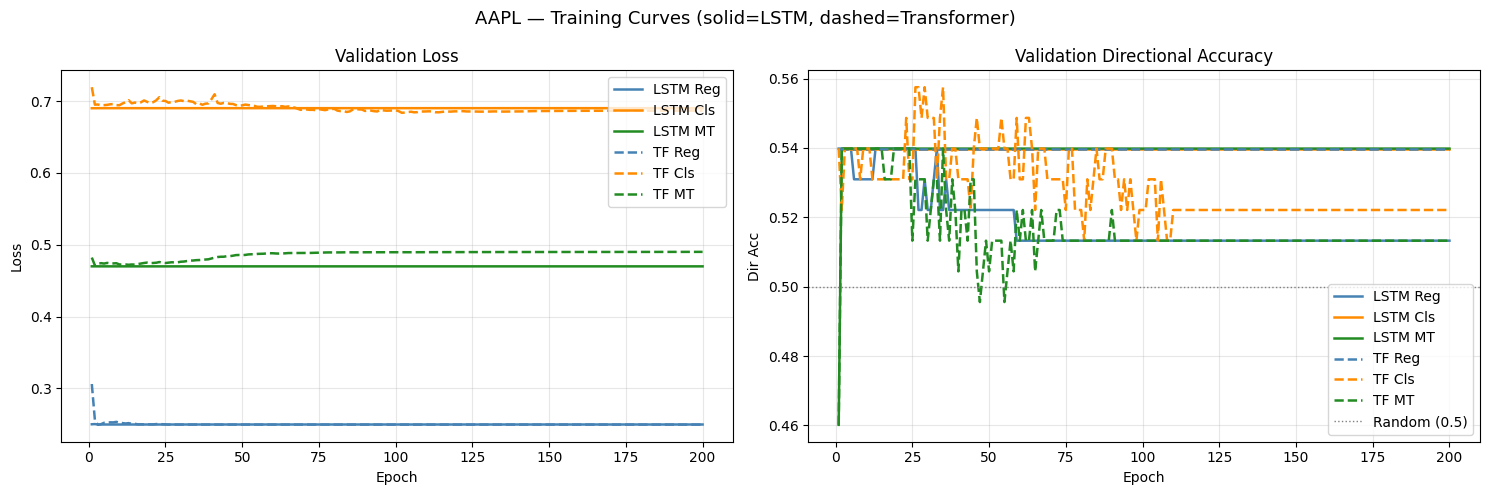

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, r in RESULTS.items():
    c, ls = COLORS[name]
    ep    = np.arange(1, len(r["history"]["val_loss"]) + 1)
    axes[0].plot(ep, r["history"]["val_loss"], color=c, linestyle=ls,
                 linewidth=1.8, label=LABELS[name])
    axes[1].plot(ep, r["history"]["val_dir"],  color=c, linestyle=ls,
                 linewidth=1.8, label=LABELS[name])

axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].set_title("Validation Directional Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dir Acc")
axes[1].axhline(0.5, color="gray", linewidth=1, linestyle=":", label="Random (0.5)")
axes[1].grid(True, alpha=0.3); axes[1].legend()

_cap = CAP_LABELS.get(FOCUS_TICKER, "")
plt.suptitle(f"{FOCUS_TICKER} ({_cap}) — Training Curves (solid=LSTM, dashed=Transformer)", fontsize=13)
plt.tight_layout()
plt.show()


## Optuna Hyperparameter Search (optional)

Set **`RUN_OPTUNA = True`** in the config cell to run all studies below; **`False`**
skips them so you can run the entire notebook in one pass (manually trained weights only).

Each study tunes the corresponding model variant and stores the best weights in
`RESULTS` (the **focus** ticker only — same object as `RESULTS_BY_TICKER[FOCUS_TICKER]`;
downloads use global `df`, i.e. the focus stock).

If Optuna is off or a study cell fails, the manually-trained model from the training
cells above is used for evaluation.


In [51]:
# Mark each entry with no Optuna result yet (FOCUS ticker only — Optuna uses global `df`)
for _bundle in RESULTS_BY_TICKER.values():
    for _name in _bundle:
        _bundle[_name].setdefault("optuna_best_state", None)
        _bundle[_name].setdefault("optuna_best_meta",  None)
for _name in RESULTS:
    RESULTS[_name].setdefault("optuna_best_state", None)
    RESULTS[_name].setdefault("optuna_best_meta",  None)

if not RUN_OPTUNA:
    print("Optuna disabled (RUN_OPTUNA=False); study cells no-op, using manually trained weights.")

if RUN_OPTUNA:
    import optuna
    from tqdm.auto import tqdm

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # ── Shared Optuna training loop ────────────────────────────────────────────
    def _optuna_train_eval(model, mode, train_l, val_l, criterion, lr, wd, n_epochs):
        """Train for n_epochs and return (last_val_loss, val_dir_acc)."""
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        sched = optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", patience=max(2, SCHEDULER_PATIENCE // 2),
            factor=SCHEDULER_FACTOR, min_lr=SCHEDULER_MIN_LR,
        )
        last_val = float("inf")
        for _ in range(n_epochs):
            run_epoch(model, train_l, mode, criterion, device, opt)
            last_val, _ = run_epoch(model, val_l, mode, criterion, device)
            sched.step(last_val)

        _, val_dir = run_epoch(model, val_l, mode, criterion, device)
        return last_val, val_dir

    def _run_study(name, make_objective, n_trials=OPTUNA_N_TRIALS, seed=OPTUNA_SEED):
        """Create a study, optimise, update RESULTS, print summary."""
        study = optuna.create_study(direction="minimize",
                                     sampler=optuna.samplers.TPESampler(seed=seed))
        pbar = tqdm(total=n_trials, desc=f"Optuna {name}", unit="trial", dynamic_ncols=True)

        def _cb(study, trial):
            pbar.update(1)
            if study.best_trial:
                d = study.best_trial.user_attrs.get("val_dir", float("nan"))
                pbar.set_postfix(best_obj=f"{study.best_value:.4f}", best_dir=f"{d:.4f}")

        try:
            study.optimize(make_objective(), n_trials=n_trials,
                           show_progress_bar=False, callbacks=[_cb])
        finally:
            pbar.close()

        bt = study.best_trial
        RESULTS[name]["optuna_best_state"] = bt.user_attrs["_state"]
        RESULTS[name]["optuna_best_meta"]  = bt.user_attrs["_meta"]
        print(f"\n{name} best params: {study.best_params}")
        print(f"{name} best val dir acc: {bt.user_attrs.get('val_dir', float('nan')):.4f}")
        return study
else:
    def _run_study(name, make_objective, n_trials=OPTUNA_N_TRIALS, seed=OPTUNA_SEED):
        return None


d:\Code\MEng_winter\ECE1508_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [52]:
def _make_lstm_reg_obj():
    def objective(trial):
        use_vol  = trial.suggest_categorical("use_vol_features", [True, False])
        atr_s    = trial.suggest_int("atr_ewm_span", 7, 21) if use_vol else None
        rv_s     = trial.suggest_int("rv_ewm_span",  10, 40) if use_vol else None
        hidden   = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
        n_layers = trial.suggest_int("num_layers", 1, 3)
        dropout  = trial.suggest_float("dropout", 0.0, 0.5)
        lr       = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
        wd       = trial.suggest_float("weight_decay",  1e-6, 1e-3, log=True)
        var_w    = trial.suggest_float("var_weight",  0.1, 5.0)
        dir_w    = trial.suggest_float("dir_weight",  0.05, 2.0)
        hinge_s  = trial.suggest_float("hinge_scale", 0.0, 1.0)

        input_dim = 5 + (NUM_VOL_FEATURES if use_vol else 0)
        p = prepare_datasets(df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
                             use_vol_features=use_vol, atr_ewm_span=atr_s, rv_ewm_span=rv_s)
        m = LSTMRegression(input_dim, hidden, n_layers, dropout).to(device)
        crit = StockReturnLoss(var_w, dir_w, hinge_s)
        _, val_dir = _optuna_train_eval(m, "regression", p["dataloaders"]["train"],
                                         p["dataloaders"]["val"], crit, lr, wd, OPTUNA_EPOCHS_PER_TRIAL)
        trial.set_user_attr("val_dir", float(val_dir) if val_dir == val_dir else float("nan"))
        trial.set_user_attr("_state", {k: v.cpu().clone() for k, v in m.state_dict().items()})
        trial.set_user_attr("_meta",  {"input_dim": input_dim, "hidden_size": hidden,
                                        "num_layers": n_layers, "dropout": dropout,
                                        "use_vol_features": use_vol, "atr_ewm_span": atr_s, "rv_ewm_span": rv_s})
        return 1.0 - val_dir if val_dir == val_dir else 1.0
    return objective

lstm_reg_study = _run_study("lstm_regression", _make_lstm_reg_obj)


Optuna lstm_regression: 100%|██████████| 20/20 [01:23<00:00,  4.17s/trial, best_dir=0.5664, best_obj=0.4336]


lstm_regression best params: {'use_vol_features': True, 'atr_ewm_span': 12, 'rv_ewm_span': 29, 'hidden_size': 64, 'num_layers': 3, 'dropout': 0.3069946802446093, 'learning_rate': 0.0005444423626001166, 'weight_decay': 7.328080301839693e-05, 'var_weight': 1.8525612644916316, 'dir_weight': 0.11503096065642737, 'hinge_scale': 0.29363528329077404}
lstm_regression best val dir acc: 0.5664


In [53]:
def _make_lstm_cls_obj():
    def objective(trial):
        use_vol  = trial.suggest_categorical("use_vol_features", [True, False])
        atr_s    = trial.suggest_int("atr_ewm_span", 7, 21) if use_vol else None
        rv_s     = trial.suggest_int("rv_ewm_span",  10, 40) if use_vol else None
        hidden   = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
        n_layers = trial.suggest_int("num_layers", 1, 3)
        dropout  = trial.suggest_float("dropout", 0.0, 0.5)
        lr       = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
        wd       = trial.suggest_float("weight_decay",  1e-6, 1e-3, log=True)

        input_dim = 5 + (NUM_VOL_FEATURES if use_vol else 0)
        p = prepare_datasets(df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
                             use_vol_features=use_vol, atr_ewm_span=atr_s, rv_ewm_span=rv_s)
        m = LSTMClassifier(input_dim, hidden, n_layers, dropout).to(device)
        _, val_dir = _optuna_train_eval(m, "classification", p["dataloaders"]["train"],
                                         p["dataloaders"]["val"], None, lr, wd, OPTUNA_EPOCHS_PER_TRIAL)
        trial.set_user_attr("val_dir", float(val_dir) if val_dir == val_dir else float("nan"))
        trial.set_user_attr("_state", {k: v.cpu().clone() for k, v in m.state_dict().items()})
        trial.set_user_attr("_meta",  {"input_dim": input_dim, "hidden_size": hidden,
                                        "num_layers": n_layers, "dropout": dropout,
                                        "use_vol_features": use_vol, "atr_ewm_span": atr_s, "rv_ewm_span": rv_s})
        return 1.0 - val_dir if val_dir == val_dir else 1.0
    return objective

lstm_cls_study = _run_study("lstm_classifier", _make_lstm_cls_obj)


Optuna lstm_classifier: 100%|██████████| 20/20 [00:51<00:00,  2.57s/trial, best_dir=0.5664, best_obj=0.4336]


lstm_classifier best params: {'use_vol_features': True, 'atr_ewm_span': 7, 'rv_ewm_span': 10, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.01936259998059159, 'learning_rate': 0.0007893413277479098, 'weight_decay': 1.085319951726647e-06}
lstm_classifier best val dir acc: 0.5664


In [54]:
def _make_lstm_mt_obj():
    def objective(trial):
        use_vol  = trial.suggest_categorical("use_vol_features", [True, False])
        atr_s    = trial.suggest_int("atr_ewm_span", 7, 21) if use_vol else None
        rv_s     = trial.suggest_int("rv_ewm_span",  10, 40) if use_vol else None
        hidden   = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
        n_layers = trial.suggest_int("num_layers", 1, 3)
        dropout  = trial.suggest_float("dropout", 0.0, 0.5)
        lr       = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
        wd       = trial.suggest_float("weight_decay",  1e-6, 1e-3, log=True)
        alpha    = trial.suggest_float("alpha", 0.1, 0.9)
        var_w    = trial.suggest_float("var_weight",  0.1, 5.0)
        dir_w    = trial.suggest_float("dir_weight",  0.05, 2.0)
        hinge_s  = trial.suggest_float("hinge_scale", 0.0, 1.0)

        input_dim = 5 + (NUM_VOL_FEATURES if use_vol else 0)
        p = prepare_datasets(df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
                             use_vol_features=use_vol, atr_ewm_span=atr_s, rv_ewm_span=rv_s)
        m    = LSTMMultiTask(input_dim, hidden, n_layers, dropout).to(device)
        crit = MultiTaskLoss(alpha, var_w, dir_w, hinge_s)
        _, val_dir = _optuna_train_eval(m, "multitask", p["dataloaders"]["train"],
                                         p["dataloaders"]["val"], crit, lr, wd, OPTUNA_EPOCHS_PER_TRIAL)
        trial.set_user_attr("val_dir", float(val_dir) if val_dir == val_dir else float("nan"))
        trial.set_user_attr("_state", {k: v.cpu().clone() for k, v in m.state_dict().items()})
        trial.set_user_attr("_meta",  {"input_dim": input_dim, "hidden_size": hidden,
                                        "num_layers": n_layers, "dropout": dropout, "alpha": alpha,
                                        "var_weight": var_w, "dir_weight": dir_w, "hinge_scale": hinge_s,
                                        "use_vol_features": use_vol, "atr_ewm_span": atr_s, "rv_ewm_span": rv_s})
        return 1.0 - val_dir if val_dir == val_dir else 1.0
    return objective

lstm_mt_study = _run_study("lstm_multitask", _make_lstm_mt_obj)


Optuna lstm_multitask: 100%|██████████| 20/20 [01:15<00:00,  3.77s/trial, best_dir=0.5487, best_obj=0.4513]


lstm_multitask best params: {'use_vol_features': False, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.06974693032602092, 'learning_rate': 0.00027010527749605503, 'weight_decay': 1.2562773503807034e-05, 'alpha': 0.46485598737362877, 'var_weight': 3.947362210825767, 'dir_weight': 0.4393638752088015, 'hinge_scale': 0.5142344384136116}
lstm_multitask best val dir acc: 0.5487


In [55]:
def _make_tf_reg_obj():
    def objective(trial):
        use_vol  = trial.suggest_categorical("use_vol_features", [True, False])
        atr_s    = trial.suggest_int("atr_ewm_span", 7, 21) if use_vol else None
        rv_s     = trial.suggest_int("rv_ewm_span",  10, 40) if use_vol else None
        d_model  = trial.suggest_categorical("d_model", [32, 64, 128])
        nhead    = trial.suggest_categorical("nhead", [2, 4])
        n_layers = trial.suggest_int("num_layers", 1, 4)
        dropout  = trial.suggest_float("dropout", 0.05, 0.45)
        dim_ff   = trial.suggest_categorical("dim_feedforward", [128, 256, 512])
        lr       = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
        wd       = trial.suggest_float("weight_decay",  1e-6, 1e-3, log=True)
        var_w    = trial.suggest_float("var_weight",  0.1, 5.0)
        dir_w    = trial.suggest_float("dir_weight",  0.05, 2.0)
        hinge_s  = trial.suggest_float("hinge_scale", 0.0, 1.0)

        input_dim = 5 + (NUM_VOL_FEATURES if use_vol else 0)
        p = prepare_datasets(df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
                             use_vol_features=use_vol, atr_ewm_span=atr_s, rv_ewm_span=rv_s)
        m    = TransformerRegression(input_dim, d_model, nhead, n_layers, dropout, dim_ff, TF_MAX_POS_LEN).to(device)
        crit = StockReturnLoss(var_w, dir_w, hinge_s)
        _, val_dir = _optuna_train_eval(m, "regression", p["dataloaders"]["train"],
                                         p["dataloaders"]["val"], crit, lr, wd, OPTUNA_EPOCHS_PER_TRIAL)
        trial.set_user_attr("val_dir", float(val_dir) if val_dir == val_dir else float("nan"))
        trial.set_user_attr("_state", {k: v.cpu().clone() for k, v in m.state_dict().items()})
        trial.set_user_attr("_meta",  {"input_dim": input_dim, "d_model": d_model, "nhead": nhead,
                                        "num_layers": n_layers, "dropout": dropout, "dim_feedforward": dim_ff,
                                        "max_pos_len": TF_MAX_POS_LEN, "use_vol_features": use_vol,
                                        "atr_ewm_span": atr_s, "rv_ewm_span": rv_s})
        return 1.0 - val_dir if val_dir == val_dir else 1.0
    return objective

tf_reg_study = _run_study("transformer_regression", _make_tf_reg_obj)


Optuna transformer_regression: 100%|██████████| 20/20 [02:02<00:00,  6.13s/trial, best_dir=0.5664, best_obj=0.4336]


transformer_regression best params: {'use_vol_features': True, 'atr_ewm_span': 11, 'rv_ewm_span': 14, 'd_model': 32, 'nhead': 2, 'num_layers': 1, 'dropout': 0.40702359939599114, 'dim_feedforward': 512, 'learning_rate': 0.00029493729440953863, 'weight_decay': 2.138729075414893e-06, 'var_weight': 1.2168822964555144, 'dir_weight': 0.8828601878211998, 'hinge_scale': 0.8180147659224931}
transformer_regression best val dir acc: 0.5664


In [56]:
def _make_tf_cls_obj():
    def objective(trial):
        use_vol  = trial.suggest_categorical("use_vol_features", [True, False])
        atr_s    = trial.suggest_int("atr_ewm_span", 7, 21) if use_vol else None
        rv_s     = trial.suggest_int("rv_ewm_span",  10, 40) if use_vol else None
        d_model  = trial.suggest_categorical("d_model", [32, 64, 128])
        nhead    = trial.suggest_categorical("nhead", [2, 4])
        n_layers = trial.suggest_int("num_layers", 1, 4)
        dropout  = trial.suggest_float("dropout", 0.05, 0.45)
        dim_ff   = trial.suggest_categorical("dim_feedforward", [128, 256, 512])
        lr       = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
        wd       = trial.suggest_float("weight_decay",  1e-6, 1e-3, log=True)

        input_dim = 5 + (NUM_VOL_FEATURES if use_vol else 0)
        p = prepare_datasets(df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
                             use_vol_features=use_vol, atr_ewm_span=atr_s, rv_ewm_span=rv_s)
        m = TransformerClassifier(input_dim, d_model, nhead, n_layers, dropout, dim_ff, TF_MAX_POS_LEN).to(device)
        _, val_dir = _optuna_train_eval(m, "classification", p["dataloaders"]["train"],
                                         p["dataloaders"]["val"], None, lr, wd, OPTUNA_EPOCHS_PER_TRIAL)
        trial.set_user_attr("val_dir", float(val_dir) if val_dir == val_dir else float("nan"))
        trial.set_user_attr("_state", {k: v.cpu().clone() for k, v in m.state_dict().items()})
        trial.set_user_attr("_meta",  {"input_dim": input_dim, "d_model": d_model, "nhead": nhead,
                                        "num_layers": n_layers, "dropout": dropout, "dim_feedforward": dim_ff,
                                        "max_pos_len": TF_MAX_POS_LEN, "use_vol_features": use_vol,
                                        "atr_ewm_span": atr_s, "rv_ewm_span": rv_s})
        return 1.0 - val_dir if val_dir == val_dir else 1.0
    return objective

tf_cls_study = _run_study("transformer_classifier", _make_tf_cls_obj)


Optuna transformer_classifier: 100%|██████████| 20/20 [01:40<00:00,  5.02s/trial, best_dir=0.5929, best_obj=0.4071]


transformer_classifier best params: {'use_vol_features': True, 'atr_ewm_span': 12, 'rv_ewm_span': 17, 'd_model': 128, 'nhead': 4, 'num_layers': 1, 'dropout': 0.2677672647943495, 'dim_feedforward': 128, 'learning_rate': 0.00019465037378698426, 'weight_decay': 0.00018730163357556502}
transformer_classifier best val dir acc: 0.5929


In [57]:
def _make_tf_mt_obj():
    def objective(trial):
        use_vol  = trial.suggest_categorical("use_vol_features", [True, False])
        atr_s    = trial.suggest_int("atr_ewm_span", 7, 21) if use_vol else None
        rv_s     = trial.suggest_int("rv_ewm_span",  10, 40) if use_vol else None
        d_model  = trial.suggest_categorical("d_model", [32, 64, 128])
        nhead    = trial.suggest_categorical("nhead", [2, 4])
        n_layers = trial.suggest_int("num_layers", 1, 4)
        dropout  = trial.suggest_float("dropout", 0.05, 0.45)
        dim_ff   = trial.suggest_categorical("dim_feedforward", [128, 256, 512])
        lr       = trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True)
        wd       = trial.suggest_float("weight_decay",  1e-6, 1e-3, log=True)
        alpha    = trial.suggest_float("alpha", 0.1, 0.9)
        var_w    = trial.suggest_float("var_weight",  0.1, 5.0)
        dir_w    = trial.suggest_float("dir_weight",  0.05, 2.0)
        hinge_s  = trial.suggest_float("hinge_scale", 0.0, 1.0)

        input_dim = 5 + (NUM_VOL_FEATURES if use_vol else 0)
        p = prepare_datasets(df, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
                             use_vol_features=use_vol, atr_ewm_span=atr_s, rv_ewm_span=rv_s)
        m    = TransformerMultiTask(input_dim, d_model, nhead, n_layers, dropout, dim_ff, TF_MAX_POS_LEN).to(device)
        crit = MultiTaskLoss(alpha, var_w, dir_w, hinge_s)
        _, val_dir = _optuna_train_eval(m, "multitask", p["dataloaders"]["train"],
                                         p["dataloaders"]["val"], crit, lr, wd, OPTUNA_EPOCHS_PER_TRIAL)
        trial.set_user_attr("val_dir", float(val_dir) if val_dir == val_dir else float("nan"))
        trial.set_user_attr("_state", {k: v.cpu().clone() for k, v in m.state_dict().items()})
        trial.set_user_attr("_meta",  {"input_dim": input_dim, "d_model": d_model, "nhead": nhead,
                                        "num_layers": n_layers, "dropout": dropout, "dim_feedforward": dim_ff,
                                        "max_pos_len": TF_MAX_POS_LEN, "alpha": alpha,
                                        "var_weight": var_w, "dir_weight": dir_w, "hinge_scale": hinge_s,
                                        "use_vol_features": use_vol, "atr_ewm_span": atr_s, "rv_ewm_span": rv_s})
        return 1.0 - val_dir if val_dir == val_dir else 1.0
    return objective

tf_mt_study = _run_study("transformer_multitask", _make_tf_mt_obj)


Optuna transformer_multitask: 100%|██████████| 20/20 [02:41<00:00,  8.05s/trial, best_dir=0.5841, best_obj=0.4159]


transformer_multitask best params: {'use_vol_features': True, 'atr_ewm_span': 17, 'rv_ewm_span': 33, 'd_model': 64, 'nhead': 4, 'num_layers': 3, 'dropout': 0.08611590802176333, 'dim_feedforward': 128, 'learning_rate': 0.00011487613841748918, 'weight_decay': 5.924870051994317e-05, 'alpha': 0.642051489473826, 'var_weight': 0.18128036174649514, 'dir_weight': 1.048581463683598, 'hinge_scale': 0.22649577519793795}
transformer_multitask best val dir acc: 0.5841


In [58]:
# For each model: if Optuna best weights exist, rebuild and load; else use the
# manually-trained model. Then run test inference and store directional accuracy.
# Runs once per ticker in `RESULTS_BY_TICKER`.

_MODEL_BUILDERS = {
    "lstm_regression":        lambda m: LSTMRegression(m["input_dim"], m["hidden_size"], m["num_layers"], m["dropout"]),
    "lstm_classifier":        lambda m: LSTMClassifier(m["input_dim"], m["hidden_size"], m["num_layers"], m["dropout"]),
    "lstm_multitask":         lambda m: LSTMMultiTask( m["input_dim"], m["hidden_size"], m["num_layers"], m["dropout"]),
    "transformer_regression": lambda m: TransformerRegression(m["input_dim"], m["d_model"], m["nhead"], m["num_layers"], m["dropout"], m["dim_feedforward"], m["max_pos_len"]),
    "transformer_classifier": lambda m: TransformerClassifier(m["input_dim"], m["d_model"], m["nhead"], m["num_layers"], m["dropout"], m["dim_feedforward"], m["max_pos_len"]),
    "transformer_multitask":  lambda m: TransformerMultiTask( m["input_dim"], m["d_model"], m["nhead"], m["num_layers"], m["dropout"], m["dim_feedforward"], m["max_pos_len"]),
}


def _eval_test_for_bundle(results_bundle: Dict, df_for_optuna):
    for name, r in results_bundle.items():
        if r.get("optuna_best_state") is not None:
            meta  = r["optuna_best_meta"]
            model = _MODEL_BUILDERS[name](meta).to(device)
            model.load_state_dict(r["optuna_best_state"])
            p = prepare_datasets(df_for_optuna, lookback=LOOKBACK, horizon=HORIZON, batch_size=BATCH_SIZE,
                                 use_vol_features=meta["use_vol_features"],
                                 atr_ewm_span=meta.get("atr_ewm_span"), rv_ewm_span=meta.get("rv_ewm_span"))
            r["eval_model"]    = model
            r["eval_prepared"] = p
            print(f"{name}: using Optuna best-trial weights.")
        else:
            r["eval_model"]    = r["model"]
            r["eval_prepared"] = r["prepared"]
            print(f"{name}: using manually-trained model.")

        preds_np, true_np = get_test_preds(r["eval_model"], r["eval_prepared"]["dataloaders"]["test"],
                                            r["mode"], device)
        r["test_preds"] = preds_np.reshape(-1)
        r["test_true"]  = true_np.reshape(-1)
        r["test_dir"]   = dir_accuracy(torch.tensor(r["test_preds"]),
                                        torch.tensor(r["test_true"]), r["mode"])


for sym, bundle in RESULTS_BY_TICKER.items():
    print(f"\n--- {sym} ({CAP_LABELS.get(sym, '')}) ---")
    _eval_test_for_bundle(bundle, DATA_BY_TICKER[sym]["df"])
    print("Test directional accuracy")
    for name, r in bundle.items():
        print(f"  {name:<28}: {r['test_dir']:.4f}")

RESULTS = RESULTS_BY_TICKER[FOCUS_TICKER]


lstm_regression: using Optuna best-trial weights.
lstm_classifier: using Optuna best-trial weights.
lstm_multitask: using Optuna best-trial weights.
transformer_regression: using Optuna best-trial weights.
transformer_classifier: using Optuna best-trial weights.
transformer_multitask: using Optuna best-trial weights.

Test directional accuracy
  lstm_regression             : 0.5487
  lstm_classifier             : 0.5752
  lstm_multitask              : 0.4956
  transformer_regression      : 0.5487
  transformer_classifier      : 0.5044
  transformer_multitask       : 0.4779


## Results

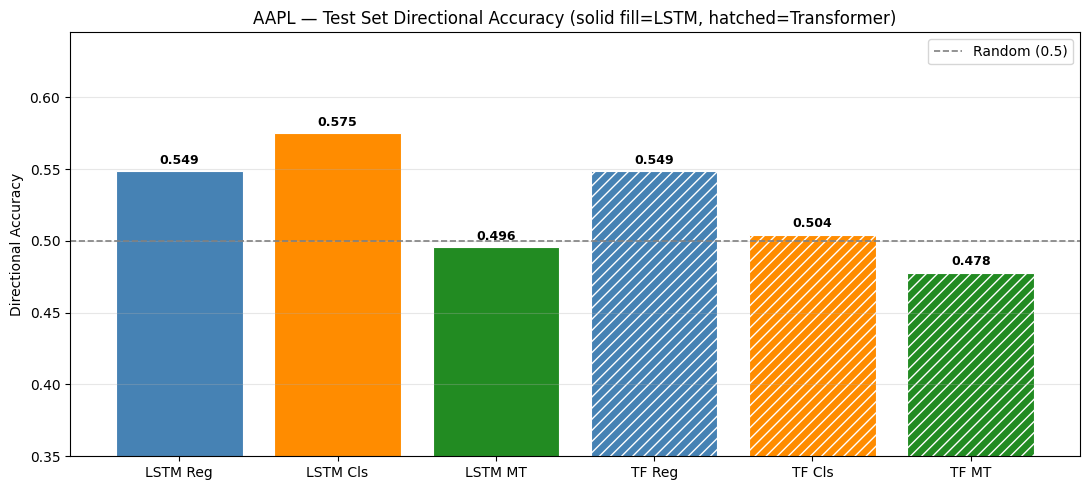


Model                          Mode             Arch            Dir Acc
------------------------------------------------------------------------
lstm_regression                regression       lstm             0.5487
lstm_classifier                classification   lstm             0.5752
lstm_multitask                 multitask        lstm             0.4956
transformer_regression         regression       transformer      0.5487
transformer_classifier         classification   transformer      0.5044
transformer_multitask          multitask        transformer      0.4779


In [59]:
names   = list(RESULTS.keys())
labels  = [LABELS.get(n, n) for n in names]

if COMPARE_ACROSS_STOCKS and len(STOCK_UNIVERSE) > 1:
    x = np.arange(len(names))
    n_t = len(STOCK_UNIVERSE)
    w = 0.8 / n_t
    fig, ax = plt.subplots(figsize=(max(12, len(names) * 2), 5.5))
    all_acc = []
    for i, (sym, cap) in enumerate(STOCK_UNIVERSE):
        offs = x - 0.4 + w / 2 + i * w
        dir_accs = [RESULTS_BY_TICKER[sym][n]["test_dir"] for n in names]
        all_acc.extend(dir_accs)
        colors = [COLORS[n][0] for n in names]
        hatches = ["" if RESULTS_BY_TICKER[sym][n]["arch"] == "lstm" else "///" for n in names]
        bars = ax.bar(offs, dir_accs, width=w, label=f"{sym} ({cap})", color=colors,
                      edgecolor="white", linewidth=0.5)
        for bar, h in zip(bars, hatches):
            bar.set_hatch(h)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=18, ha="right")
    ax.axhline(0.5, color="gray", linewidth=1.2, linestyle="--", label="Random (0.5)")
    hi = max(all_acc) if all_acc else 0.6
    ax.set_ylim(0.35, hi + 0.08)
    ax.set_title("Test directional accuracy — comparison across tickers (solid fill=LSTM, hatched=Transformer)", fontsize=12)
    ax.set_ylabel("Directional Accuracy")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
else:
    dir_accs = [RESULTS[n]["test_dir"] for n in names]
    colors   = [COLORS[n][0] for n in names]
    hatches  = ["" if RESULTS[n]["arch"] == "lstm" else "///" for n in names]
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(labels, dir_accs, color=colors, edgecolor="white", linewidth=0.8)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    ax.axhline(0.5, color="gray", linewidth=1.2, linestyle="--", label="Random (0.5)")
    for bar, v in zip(bars, dir_accs):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0.35, max(dir_accs) + 0.07)
    _t = FOCUS_TICKER
    _c = CAP_LABELS.get(_t, "")
    ax.set_title(f"{_t} ({_c}) — Test Set Directional Accuracy (solid fill=LSTM, hatched=Transformer)", fontsize=12)
    ax.set_ylabel("Directional Accuracy")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table(s)
if COMPARE_ACROSS_STOCKS and len(STOCK_UNIVERSE) > 1:
    for sym, cap in STOCK_UNIVERSE:
        print(f"\n=== {sym} ({cap}) ===")
        print(f"{'Model':<30} {'Mode':<16} {'Arch':<14} {'Dir Acc':>8}")
        print("-" * 72)
        for name, r in RESULTS_BY_TICKER[sym].items():
            print(f"{name:<30} {r['mode']:<16} {r['arch']:<14} {r['test_dir']:>8.4f}")
    print("\n--- Pivot: test_dir ---")
    _rows = []
    for sym, cap in STOCK_UNIVERSE:
        for name in names:
            _rows.append({"ticker": sym, "cap": cap, "model": name,
                          "test_dir": RESULTS_BY_TICKER[sym][name]["test_dir"]})
    _df = pd.DataFrame(_rows)
    print(_df.pivot(index="model", columns="ticker", values="test_dir").round(4))
else:
    print(f"\n{'Model':<30} {'Mode':<16} {'Arch':<14} {'Dir Acc':>8}")
    print("-" * 72)
    for name, r in RESULTS.items():
        print(f"{name:<30} {r['mode']:<16} {r['arch']:<14} {r['test_dir']:>8.4f}")


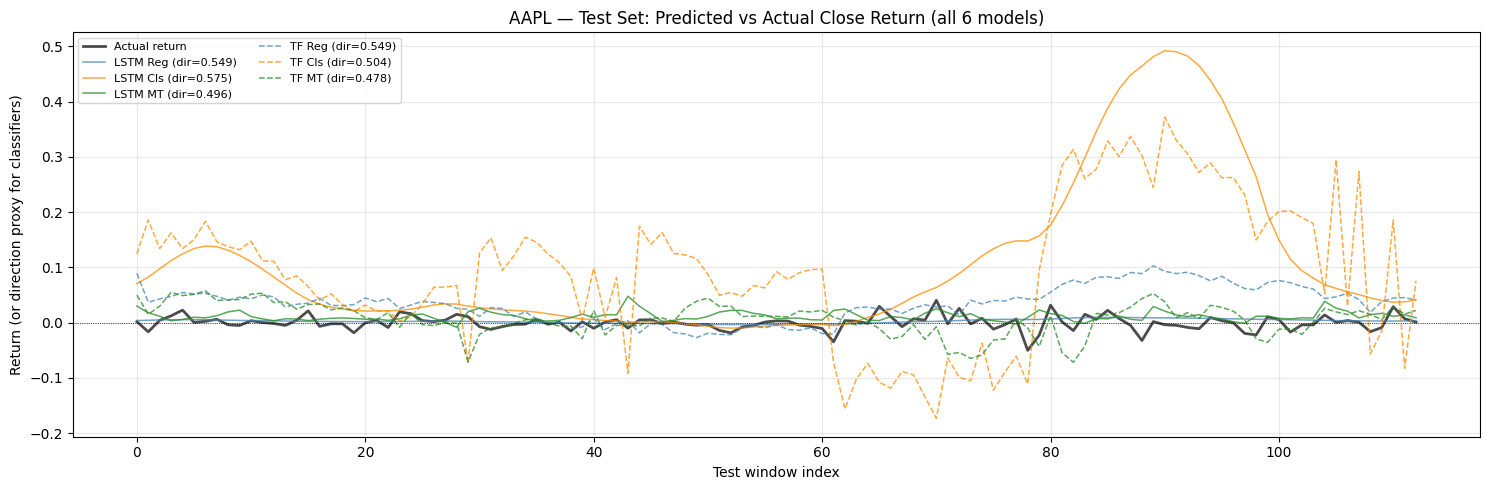

In [60]:
# For classification models, predictions are probabilities -> convert to signed return proxy:
#   (prob - 0.5) * 2  gives a value in [-1, 1] preserving sign
def _to_signed(preds_np, mode):
    if mode == "classification":
        return (preds_np - 0.5) * 2.0
    return preds_np  # regression / multitask already return signed values

actual = RESULTS["lstm_regression"]["test_true"]  # same targets for all
x = np.arange(len(actual))

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(x, actual, label="Actual return", linewidth=2, color="black", alpha=0.7)
for name, r in RESULTS.items():
    c, ls = COLORS[name]
    signed = _to_signed(r["test_preds"], r["mode"])
    ax.plot(x, signed, label=f"{LABELS[name]} (dir={r['test_dir']:.3f})",
            linewidth=1.1, color=c, linestyle=ls, alpha=0.75)
ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax.set_title(f"{FOCUS_TICKER} ({CAP_LABELS.get(FOCUS_TICKER, '')}) — Test Set: Predicted vs Actual Close Return (all 6 models)")
ax.set_xlabel("Test window index")
ax.set_ylabel("Return (or direction proxy for classifiers)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


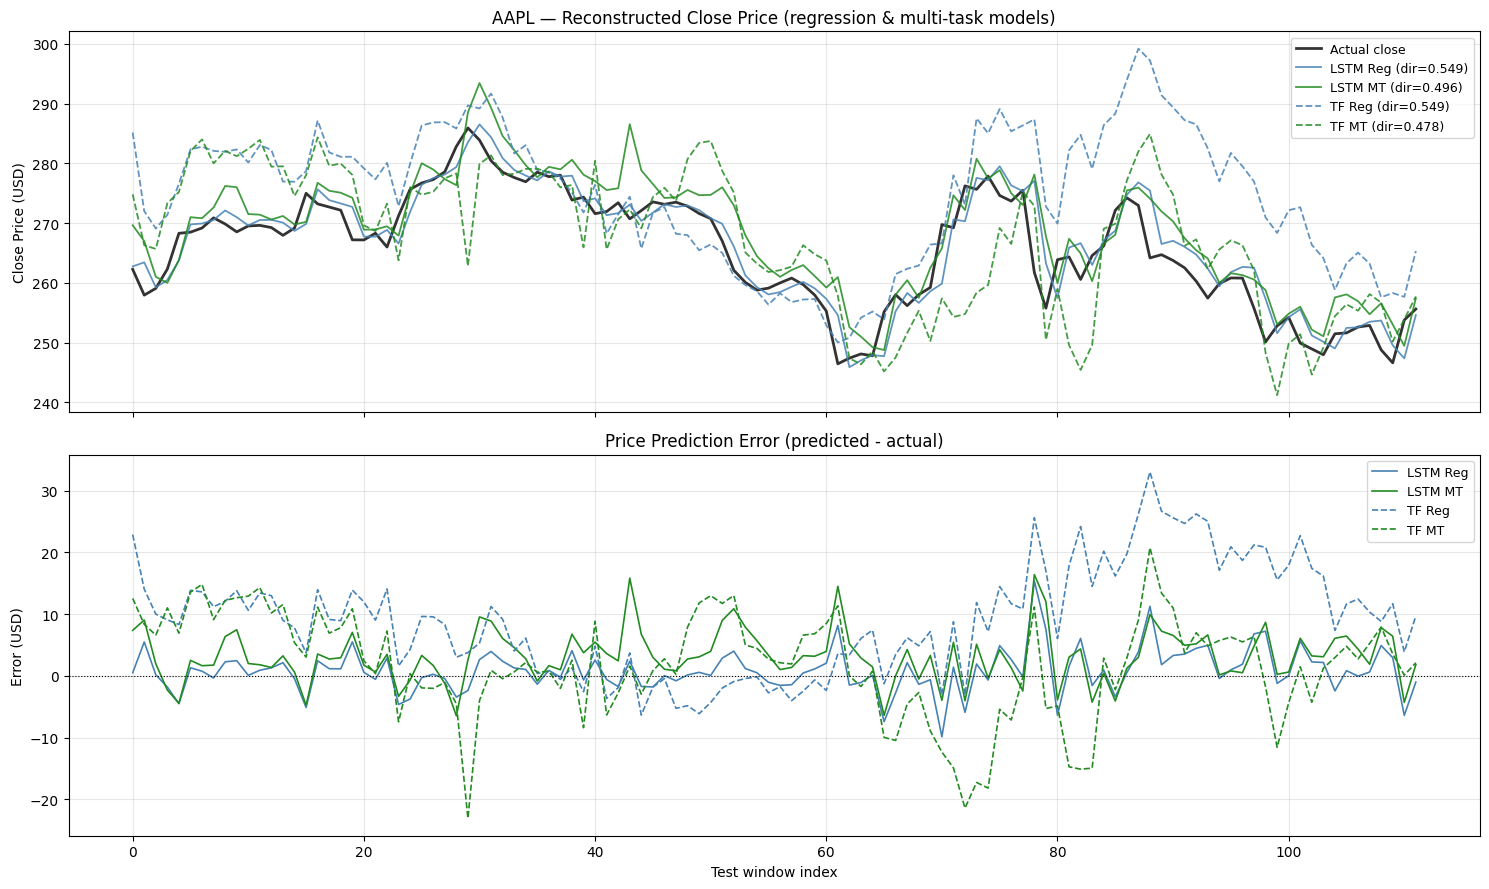


Model                               MAE      RMSE   Dir Acc
--------------------------------------------------------------
lstm_regression                  2.5267    3.5978    0.5487
lstm_multitask                   4.1922    5.2759    0.4956
transformer_regression          10.1535   12.6227    0.5487
transformer_multitask            6.8390    8.6023    0.4779


In [61]:
# Price reconstruction: predicted_close[t] = prev_close[t-1] * (1 + predicted_return[t])
# Only makes sense for regression and multi-task models (real return predictions).

returns_df_plot = prepared["returns_df"]
n_returns       = len(returns_df_plot)
val_end_idx     = int(n_returns * VAL_END_FRAC)
first_test_idx  = val_end_idx + 1   # offset by 1 (pct_change drops row 0)

actual_true = RESULTS["lstm_regression"]["test_true"]
n_plot      = min(len(actual_true), len(df) - first_test_idx - 1)

actual_closes = df["close"].iloc[first_test_idx : first_test_idx + n_plot].values
prev_closes   = df["close"].iloc[first_test_idx - 1 : first_test_idx - 1 + n_plot].values
x_price       = np.arange(n_plot)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# Top: price series
axes[0].plot(x_price, actual_closes, label="Actual close", linewidth=2, color="black", alpha=0.8)

price_models = {k: v for k, v in RESULTS.items() if v["mode"] in ("regression", "multitask")}
for name, r in price_models.items():
    pred_closes = prev_closes * (1.0 + r["test_preds"][:n_plot])
    c, ls = COLORS[name]
    axes[0].plot(x_price, pred_closes, label=f"{LABELS[name]} (dir={r['test_dir']:.3f})",
                 linewidth=1.3, color=c, linestyle=ls, alpha=0.85)

axes[0].set_title(f"{FOCUS_TICKER} ({CAP_LABELS.get(FOCUS_TICKER, '')}) — Reconstructed Close Price (regression & multi-task models)")
axes[0].set_ylabel("Close Price (USD)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom: prediction error
for name, r in price_models.items():
    pred_closes = prev_closes * (1.0 + r["test_preds"][:n_plot])
    c, ls = COLORS[name]
    axes[1].plot(x_price, pred_closes - actual_closes,
                 label=LABELS[name], color=c, linestyle=ls, linewidth=1.2)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[1].set_title("Price Prediction Error (predicted - actual)")
axes[1].set_xlabel("Test window index")
axes[1].set_ylabel("Error (USD)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# MAE / RMSE table
print(f"\n{'Model':<30} {'MAE':>8}  {'RMSE':>8}  {'Dir Acc':>8}")
print("-" * 62)
for name, r in price_models.items():
    pc = prev_closes * (1.0 + r["test_preds"][:n_plot])
    mae  = np.mean(np.abs(pc - actual_closes))
    rmse = np.sqrt(np.mean((pc - actual_closes) ** 2))
    print(f"{name:<30} {mae:>8.4f}  {rmse:>8.4f}  {r['test_dir']:>8.4f}")


RuntimeError: input.size(-1) must be equal to input_size. Expected 7, got 5

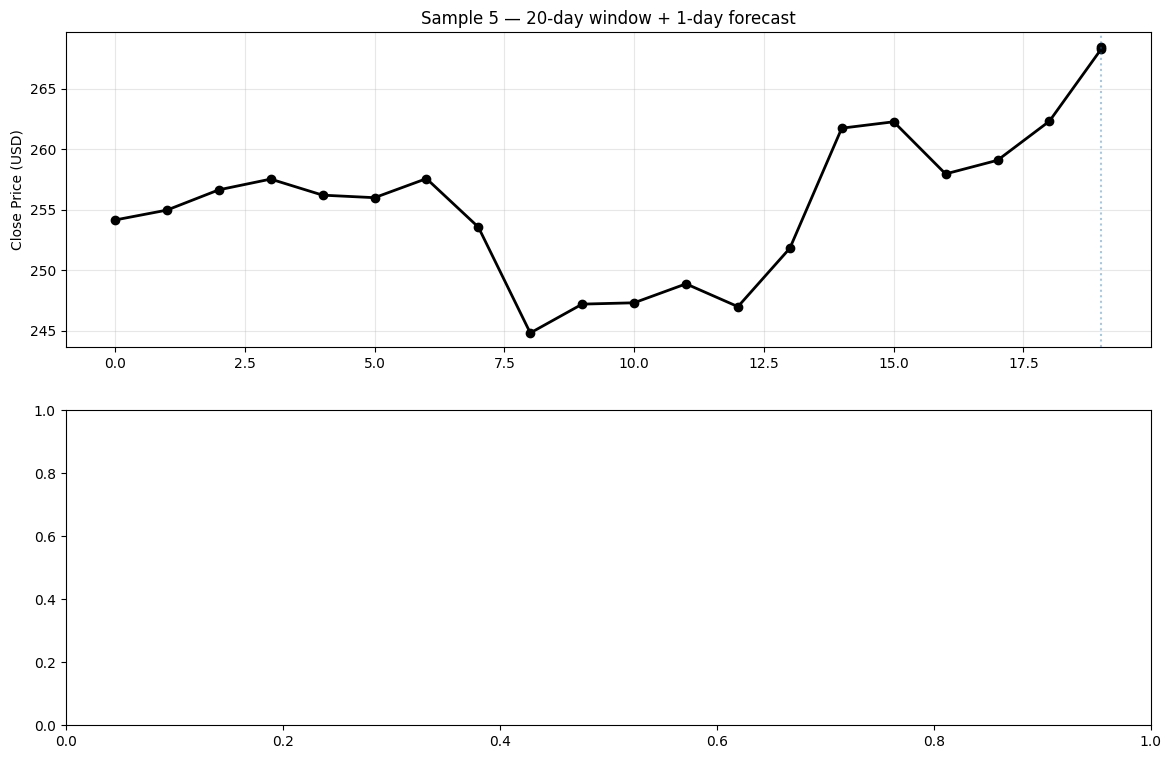

In [62]:
# Single-sample LOOKBACK window + HORIZON-step forecast for all price-capable models.

test_dataset = prepared["dataloaders"]["test"].dataset
single_X, single_y = test_dataset[SAMPLE_IDX]
single_X_dev = single_X.unsqueeze(0).to(device)

sample_df_idx    = first_test_idx + SAMPLE_IDX
last_known_close = df["close"].iloc[sample_df_idx - 1]
actual_next      = df["close"].iloc[sample_df_idx : sample_df_idx + HORIZON].values
history_close    = df["close"].iloc[sample_df_idx - LOOKBACK : sample_df_idx].values

hist_x = np.arange(LOOKBACK)
fut_x  = np.arange(LOOKBACK - 1, LOOKBACK - 1 + HORIZON)
ret_x  = np.arange(HORIZON)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

ax1.plot(hist_x, history_close,  marker="o", linewidth=2, color="black", label="Historical close")
ax1.plot(fut_x,  actual_next,    marker="o", linewidth=2.5, color="black", linestyle="--", label="Actual future close")
ax1.axvline(x=LOOKBACK - 1, linestyle=":", alpha=0.4)
ax1.set_title(f"Sample {SAMPLE_IDX} — {LOOKBACK}-day window + {HORIZON}-day forecast")
ax1.set_ylabel("Close Price (USD)")
ax1.grid(True, alpha=0.3)

n_bar   = len(price_models)
offsets = np.linspace(-0.3, 0.3, n_bar)

for i, (name, r) in enumerate(price_models.items()):
    model = r["eval_model"]
    model.eval()
    with torch.no_grad():
        out = model(single_X_dev)
        if isinstance(out, tuple):
            out = out[0]  # use regression head for price
    ret_sample = out.cpu().numpy().flatten()[:HORIZON]
    pred_close = last_known_close * np.cumprod(1 + ret_sample)
    c, ls = COLORS[name]
    ax1.plot(fut_x, pred_close, marker="s", linewidth=2, color=c,
             linestyle=ls, label=f"{LABELS[name]} forecast")
    ax2.bar(ret_x + offsets[i], ret_sample, width=0.6 / n_bar,
            label=LABELS[name], color=c, alpha=0.8)

ax1.legend(fontsize=8)

actual_rets = single_y.numpy().flatten()[:HORIZON]
ax2.bar(ret_x + offsets[-1] + 0.6 / n_bar, actual_rets, width=0.6 / n_bar,
        label="Actual return", color="black", alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Predicted vs Actual Percent Returns")
ax2.set_xlabel("Forecast step")
ax2.set_ylabel("Return (fraction)")
ax2.set_xticks(ret_x)
ax2.set_xticklabels([f"t+{i+1}" for i in ret_x])
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
